# UK Regional Housing & Geopolitical Macro Analysis (2019-2026)
This notebook analyzes how regional housing markets across the UK (from London to Scotland) have responded to the massive shifts in the Bank of England Base Rate, driven by successive global geopolitical shocks.

## Intersecting the Local with the Global
House prices do not exist in a vacuum. We will map the UK HPI data geographically against central banking policy to identify exactly which regions are bleeding value and which are insulated.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load BoE Base Rate
df_boe = pd.read_csv('../output/boe_base_rate.csv')
df_boe['Date'] = pd.to_datetime(df_boe['DATE'])
df_boe = df_boe.set_index('Date').resample('M').last()
df_boe = df_boe['2019-01-01':].ffill()

# Load Regional HPI
df_hpi = pd.read_csv('../output/uk_hpi_data.csv', low_memory=False)
df_hpi['Date'] = pd.to_datetime(df_hpi['Date'], format='%d/%m/%Y')

# Filter for broad regions
target_regions = [
    'London', 'South East', 'East of England', 
    'West Midlands Region', 'North West', 'Yorkshire and The Humber',
    'North East', 'Scotland', 'Wales'
]
df_hpi_filtered = df_hpi[df_hpi['RegionName'].isin(target_regions)].copy()

# Pivot the data to get regions as columns over time
pivot_prices = df_hpi_filtered.pivot_table(index='Date', columns='RegionName', values='AveragePrice', aggfunc='mean')
pivot_prices = pivot_prices.resample('M').last()['2019-01-01':]

pivot_growth = df_hpi_filtered.pivot_table(index='Date', columns='RegionName', values='12m%Change', aggfunc='mean')
pivot_growth = pivot_growth.resample('M').last()['2019-01-01':]

# Calculate absolute % return from Jan 2019
pivot_returns = (pivot_prices / pivot_prices.iloc[0]) * 100 - 100

display(pivot_prices.tail())


C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_35520\3351043569.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_boe = df_boe.set_index('Date').resample('M').last()


C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_35520\3351043569.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pivot_prices = pivot_prices.resample('M').last()['2019-01-01':]
C:\Users\luigi_enjoy-digital\AppData\Local\Temp\ipykernel_35520\3351043569.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pivot_growth = pivot_growth.resample('M').last()['2019-01-01':]


RegionName,East of England,London,North East,North West,Scotland,South East,Wales,West Midlands Region,Yorkshire and The Humber
Date,,,,,,,,,
2025-08-31,340408.0,564063.0,161608.0,216329.0,192196.0,386091.0,211259.0,249663.0,206107.0
2025-09-30,339271.0,561973.0,162003.0,214509.0,193036.0,383037.0,210373.0,248375.0,206581.0
2025-10-31,341074.0,547661.0,163273.0,215026.0,192825.0,384639.0,210324.0,247888.0,206401.0
2025-11-30,339295.0,555991.0,167677.0,218243.0,193909.0,381565.0,209388.0,248535.0,209467.0
2025-12-31,338002.0,551294.0,165257.0,217428.0,190649.0,378800.0,214883.0,246141.0,208447.0


## 1. Regional Disparities: The Expensive South vs. The Resilient North
When the Bank of England drastically hiked the Base Rate to combat imported inflation, it disproportionately destroyed affordability in high-value regions.

**Geopolitical Context (The First Energy Shock):**
* In late 2021 and primarily 2022, the **War in Ukraine** caused a massive shock to global gas supplies. Although the UK imports little direct Russian gas, European shortages violently surged international wholesale prices, forcing UK CPI inflation to an 11.1% peak ([Reuters, Energy.gov](https://www.energy.gov)).
* To combat this imported cost-of-living crisis, the Bank of England engaged in a 14-hike sprint to a robust **5.25% Base Rate**. This instantly cratered mortgage affordability. 


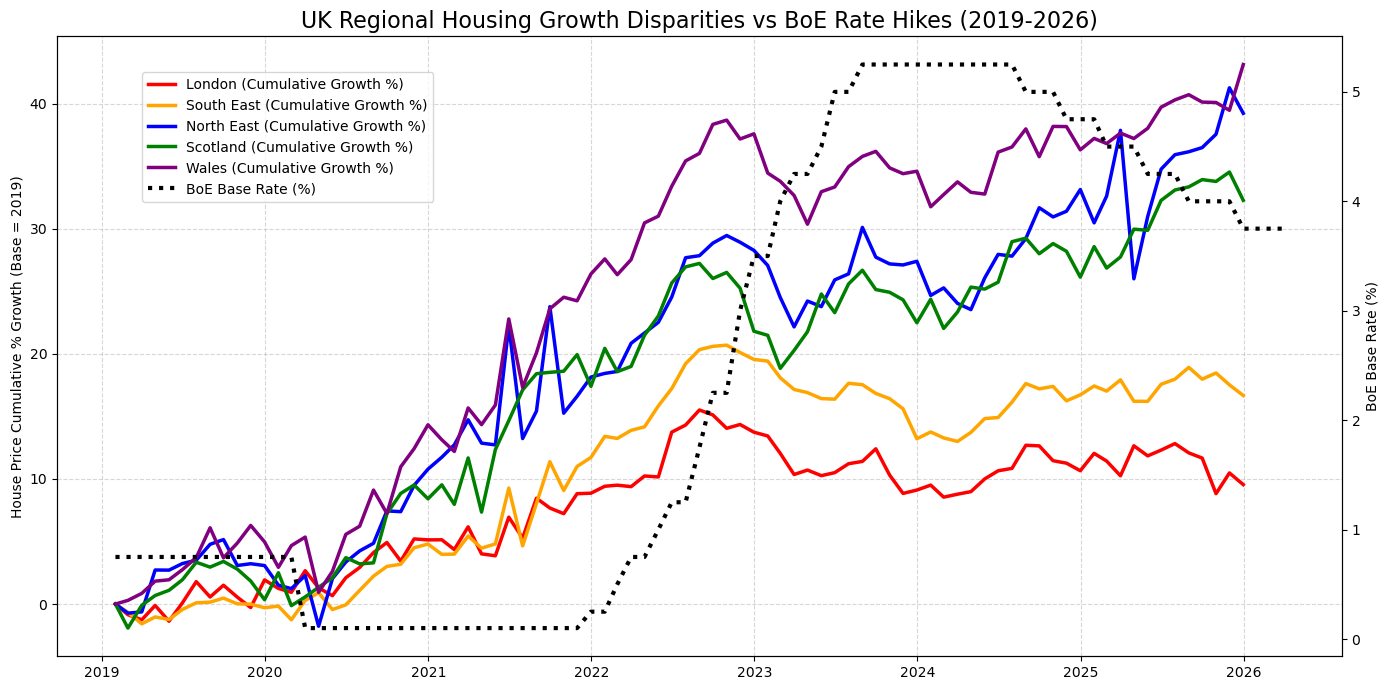

In [2]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot selected regions returns
colors = {'London': 'red', 'South East': 'orange', 'North East': 'blue', 'Scotland': 'green', 'Wales': 'purple'}
for col in colors.keys():
    if col in pivot_returns.columns:
        ax1.plot(pivot_returns.index, pivot_returns[col], label=f'{col} (Cumulative Growth %)', color=colors[col], linewidth=2.5)

ax1.set_ylabel('House Price Cumulative % Growth (Base = 2019)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Overlay BoE Base rate
ax2 = ax1.twinx()
ax2.plot(df_boe.index, df_boe['IUDBEDR'], label='BoE Base Rate (%)', color='black', linestyle=':', linewidth=3)
ax2.set_ylabel('BoE Base Rate (%)')

plt.title('UK Regional Housing Growth Disparities vs BoE Rate Hikes (2019-2026)', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.savefig('../output/chart_regional_hpi_disparity.png')
plt.show()


## 2. Global Supply Chains & "Higher for Longer" Rates
The North East and Scotland initially shrugged off the rate hikes much better than London, simply because property base prices were lower (meaning the proportional jump in monthly mortgage costs was less devastating to median local incomes).

**Geopolitical Context (The Second Energy/Supply Shock):**
* Moving into 2024 through 2026, a new wave of localized inflation is being sustained by the **Iran-Israel-USA hostilities**. Escalations surrounding the Strait of Hormuz—a chokepoint handling ~20% of global oil—have caused deep volatility. Warnings suggest Brent crude could violently surge above $100/barrel under escalation ([Al-Monitor, Goldman Sachs](https://www.al-monitor.com)).
* This structural threat of rolling commodity shocks acts as a "second-round" inflationary anchor. It forces central banks to hold a "higher for longer" posture. As seen in the graphs, an extended 5.25% base rate plateau begins flatlining even the resilient Northern housing gains.


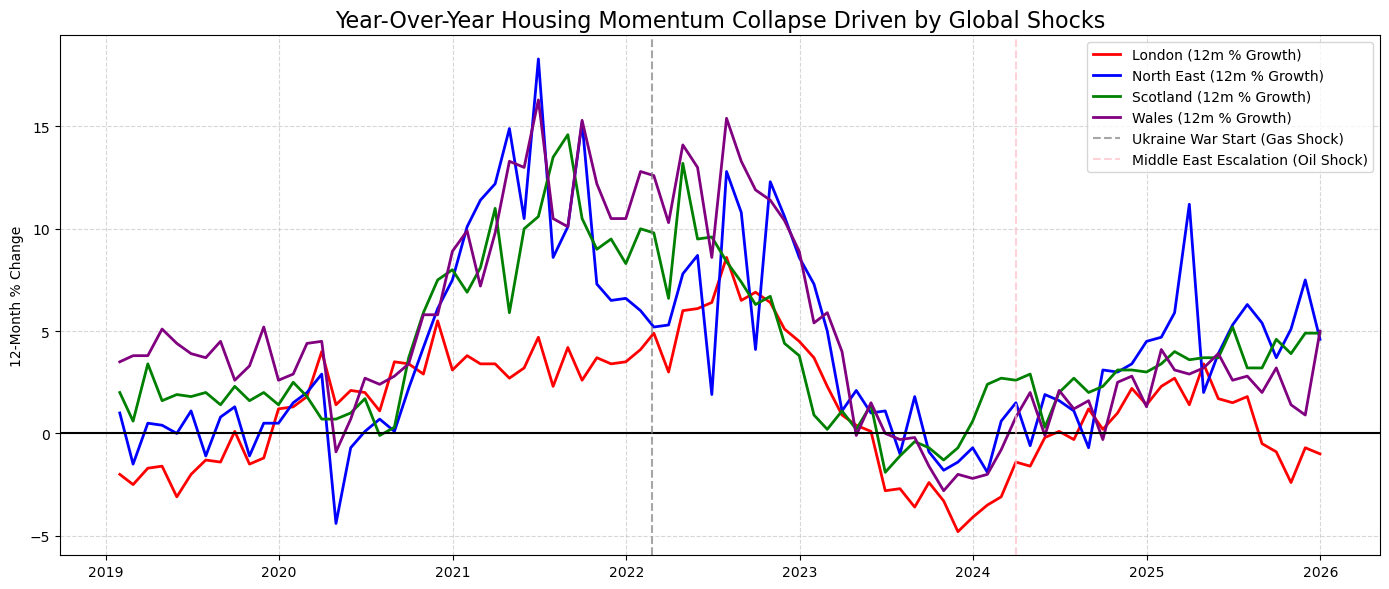

In [3]:
plt.figure(figsize=(14, 6))

# Mapping year-over-year momentum collapse
plt.plot(pivot_growth.index, pivot_growth['London'], label='London (12m % Growth)', color='red', linewidth=2)
plt.plot(pivot_growth.index, pivot_growth['North East'], label='North East (12m % Growth)', color='blue', linewidth=2)
plt.plot(pivot_growth.index, pivot_growth['Scotland'], label='Scotland (12m % Growth)', color='green', linewidth=2)
plt.plot(pivot_growth.index, pivot_growth['Wales'], label='Wales (12m % Growth)', color='purple', linewidth=2)

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(pd.to_datetime('2022-02-24'), color='grey', linestyle='--', alpha=0.7, label='Ukraine War Start (Gas Shock)')
plt.axvline(pd.to_datetime('2024-04-01'), color='pink', linestyle='--', alpha=0.7, label='Middle East Escalation (Oil Shock)')

plt.title('Year-Over-Year Housing Momentum Collapse Driven by Global Shocks', fontsize=16)
plt.ylabel('12-Month % Change')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('../output/chart_regional_momentum_collapse.png')
plt.show()
